In [1]:
from logging import setLogRecordFactory
from selenium import webdriver
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.by import By
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
import time

In [3]:
class Parser:
    def __init__(self, headers = None):
        if headers is None:
            headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
        self.headers = headers
        self.session = requests.Session()

    def parse_page(self, url):
        a = self.session.get(url, headers=self.headers)
        a.raise_for_status()
        b = BeautifulSoup(a.text, 'html.parser')
        return b

    def stop_parsing(self):
        self.session.close()
    def new_parsing(self):
        self.session = requests.Session()


In [4]:
desserts = Parser()
names_1 = []
prices_1 = []
d_p = desserts.parse_page('https://vkusvill.ru/goods/sladosti-i-deserty/sladosti-do-200-kkal/?PAGEN_1=2')

def parsing_vkusvill(x):
    for i in x.find_all('div', class_='ProductCard__content'):
        tekst = i.find('span', itemprop="name")
        names_1.append(tekst.get_text(strip=True))
        prise = i.find('span', class_='Price subtitle _desktop-md _mobile-sm Price--gray Price--label')
        prices_1.append(prise.get_text(strip=True))
parsing_vkusvill(d_p)

for k in d_p.find_all('a', class_="VV_Pager__Item"):
    q = 'https://vkusvill.ru' + k['href']
    r = desserts.parse_page(q)
    parsing_vkusvill(r)
table_d = pd.DataFrame()
table_d['Название'] = names_1
table_d['Цена'] = prices_1
print(table_d)

                                              Название       Цена
0                                Зефир воздушный, 15 г   46руб/шт
1    Батончик из белевской яблочной пастилы с черно...   79руб/шт
2            Конфета протеиновая с начинкой "Фисташка"   92руб/шт
3                              Драже "Изюм в шоколаде"  126руб/шт
4                   Желе фруктовые и ягодные "Слуперы"  125руб/шт
..                                                 ...        ...
118    Шоколадная фигурка из молочного шок. с печеньем   49руб/шт
119             Батончик протеиновый с малиной и кешью  187руб/шт
120  Батончик из белевской яблочной пастилы с брусн...   80руб/шт
121                    Шоколад без сахара на изомальте  123руб/шт
122               Карамель леденцовая "Ассорти вкусов"   90руб/шт

[123 rows x 2 columns]


In [5]:
table_d['Цена'] = table_d['Цена'].str.replace('руб/шт', '')
table_d['Цена'] = table_d['Цена'].astype(int)
print(table_d)
desserts.stop_parsing()

                                              Название  Цена
0                                Зефир воздушный, 15 г    46
1    Батончик из белевской яблочной пастилы с черно...    79
2            Конфета протеиновая с начинкой "Фисташка"    92
3                              Драже "Изюм в шоколаде"   126
4                   Желе фруктовые и ягодные "Слуперы"   125
..                                                 ...   ...
118    Шоколадная фигурка из молочного шок. с печеньем    49
119             Батончик протеиновый с малиной и кешью   187
120  Батончик из белевской яблочной пастилы с брусн...    80
121                    Шоколад без сахара на изомальте   123
122               Карамель леденцовая "Ассорти вкусов"    90

[123 rows x 2 columns]


In [9]:
driver = webdriver.Chrome()
driver.get('https://nosugarbakery.ru/menu#!/tab/916281403-1')

wait = WebDriverWait(driver, 10)
category_buttons = wait.until(EC.presence_of_all_elements_located(
            (By.CSS_SELECTOR, ".t395__title.t-name.t-name_xs")
        ))


all_dishes = []
for idx, btn in enumerate(category_buttons):
    driver.execute_script("arguments[0].click();", btn)
    time.sleep(3)
    while True:
        try:
                load_more = driver.find_element(By.CSS_SELECTOR, ".t-btn.t-btnflex.t-btnflex_type_button.t-btnflex_xs.js-store-load-more-btn.t-store__load-more-btn")
                load_more.click()
                time.sleep(5)
                break

        except:
                break

    product_cards = driver.find_elements(By.CSS_SELECTOR, ".t-store__card")

    for card in product_cards:
                try:
                    name_elem = card.find_element(By.CLASS_NAME, "t-store__card__title")
                    name = name_elem.text.strip()

                    price_elem = card.find_element(By.CLASS_NAME, "t-store__card__price-value")
                    price = price_elem.text.strip().replace("р.", "").replace(" ", "")

                    if name and price:
                        all_dishes.append({
                            "Название": name,
                            "Цена": price
                        })
                except Exception:
                    continue



table_2 = pd.DataFrame(all_dishes)
print(table_2)


driver.quit()


                                             Название  Цена
0                                     Шоколадный кекс   410
1                                      Пирог с вишней   620
2                                    Баскский чизкейк   790
3                                         Груша-банан   750
4                           Печенье шоколадный брауни   350
5                Печенье овсяное с шоколадной крошкой   350
6                                        Десерт Кокос   730
7                                       Эклер ягодный   790
8                                 Миндальный круассан   750
9                                Клубника со сливками   770
10                                       Десерт Банан   770
11                                        Лесной орех   740
12                     Шоколадный с черной смородиной   790
13                                           Тирамису   770
14                                     Земляника-личи   790
15                                 Трюфе

In [10]:
table_2 = table_2[table_2['Название'] != 'Футболка']
table_2['Цена'] = table_2['Цена'].astype(int)
table_2.drop_duplicates(inplace=True)
table_2.reset_index(inplace=True, drop=True)
print(table_2)

                                             Название  Цена
0                                     Шоколадный кекс   410
1                                      Пирог с вишней   620
2                                    Баскский чизкейк   790
3                                         Груша-банан   750
4                           Печенье шоколадный брауни   350
5                Печенье овсяное с шоколадной крошкой   350
6                                        Десерт Кокос   730
7                                       Эклер ягодный   790
8                                 Миндальный круассан   750
9                                Клубника со сливками   770
10                                       Десерт Банан   770
11                                        Лесной орех   740
12                     Шоколадный с черной смородиной   790
13                                           Тирамису   770
14                                     Земляника-личи   790
15                                 Трюфе

In [11]:
driver = webdriver.Chrome()
driver.get('https://ti.pitadobraw.ru/')
product_cards_2 = driver.find_elements(By.CSS_SELECTOR, ".t-store__card")
all_dishes_2 = []


current_scroll = driver.execute_script("return window.pageYOffset")
max_scroll = driver.execute_script("return document.body.scrollHeight - window.innerHeight")


while current_scroll < max_scroll - 999:

    product_cards_2 = driver.find_elements(By.CSS_SELECTOR, ".t-store__card")

    for card in product_cards_2:
        try:
            name_elem = card.find_element(By.CSS_SELECTOR, ".js-product-name")
            name = name_elem.text.strip()

            price_elem = card.find_element(By.CSS_SELECTOR, ".js-product-price")
            price = price_elem.text.strip().replace(" ", "").replace("р.", "")

            if name and price:
                all_dishes_2.append({
                    "Название": name,
                    "Цена": price
                })
            if name == 'Соус Цезарь':
                break
        except Exception:
            continue
    current_scroll = driver.execute_script("return window.pageYOffset")
    try:
        driver.execute_script("window.scrollBy(0, 1000);")
    except:
        break


while current_scroll < max_scroll:
    product_cards_2 = driver.find_elements(By.CSS_SELECTOR, ".t-store__card")

    for card in product_cards_2:
        try:
            name_elem = card.find_element(By.CSS_SELECTOR, ".js-product-name")
            name = name_elem.text.strip()

            price_elem = card.find_element(By.CSS_SELECTOR, ".js-product-price")
            price = price_elem.text.strip().replace(" ", "").replace("р.", "")

            if name and price:
                all_dishes_2.append({
                    "Название": name,
                    "Цена": price
                })
        except Exception:
            continue
    current_scroll = driver.execute_script("return window.pageYOffset")
    try:
        driver.execute_script("window.scrollBy(0, 1);")
    except:
        break

driver.execute_script("window.scrollTo(0, document.body.scrollHeight - 100);")
product_cards_2 = driver.find_elements(By.CSS_SELECTOR, ".t-store__card")
for card in product_cards_2:
        try:
            name_elem = card.find_element(By.CSS_SELECTOR, ".js-product-name")
            name = name_elem.text.strip()

            price_elem = card.find_element(By.CSS_SELECTOR, ".js-product-price")
            price = price_elem.text.strip().replace(" ", "").replace("р.", "")

            if name and price:
                all_dishes_2.append({
                    "Название": name,
                    "Цена": price
                })
        except Exception:
            continue


driver.execute_script("window.scrollTo(0, document.body.scrollHeight-10);")
product_cards_2 = driver.find_elements(By.CSS_SELECTOR, ".t-store__card")
for card in product_cards_2:
        try:
            name_elem = card.find_element(By.CSS_SELECTOR, ".js-product-name")
            name = name_elem.text.strip()

            price_elem = card.find_element(By.CSS_SELECTOR, ".js-product-price")
            price = price_elem.text.strip().replace(" ", "").replace("р.", "")

            if name and price:
                all_dishes_2.append({
                    "Название": name,
                    "Цена": price
                })
        except Exception:
            continue

table_3 = pd.DataFrame(all_dishes_2)
table_3 = table_3.drop_duplicates()
print(table_3)

driver.quit()

                                            Название  Цена
0      Шоколад протеиновый с миндалем by СИЛА DOBRAW  3300
1       Шоколад протеиновый с пеканом by СИЛА DOBRAW  3900
2     Шоколад протеиновый с фисташкой by СИЛА DOBRAW  4600
3       Шоколад протеиновый кунжутный by СИЛА DOBRAW  3100
4                                           Геркулес   650
...                                              ...   ...
2359                                   Соус Дзадзыки   120
2360                                     Сырный соус   160
2361                                    Терияки соус    90
2362                                    Тонкацу соус    90
2363                                     Соус Цезарь   150

[126 rows x 2 columns]


In [12]:
table_3.reset_index(drop=True, inplace=True)
print(table_3)


                                           Название  Цена
0     Шоколад протеиновый с миндалем by СИЛА DOBRAW  3300
1      Шоколад протеиновый с пеканом by СИЛА DOBRAW  3900
2    Шоколад протеиновый с фисташкой by СИЛА DOBRAW  4600
3      Шоколад протеиновый кунжутный by СИЛА DOBRAW  3100
4                                          Геркулес   650
..                                              ...   ...
121                                   Соус Дзадзыки   120
122                                     Сырный соус   160
123                                    Терияки соус    90
124                                    Тонкацу соус    90
125                                     Соус Цезарь   150

[126 rows x 2 columns]


C:\Users\user\AppData\Local\Temp\ipykernel_17584\1758490126.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


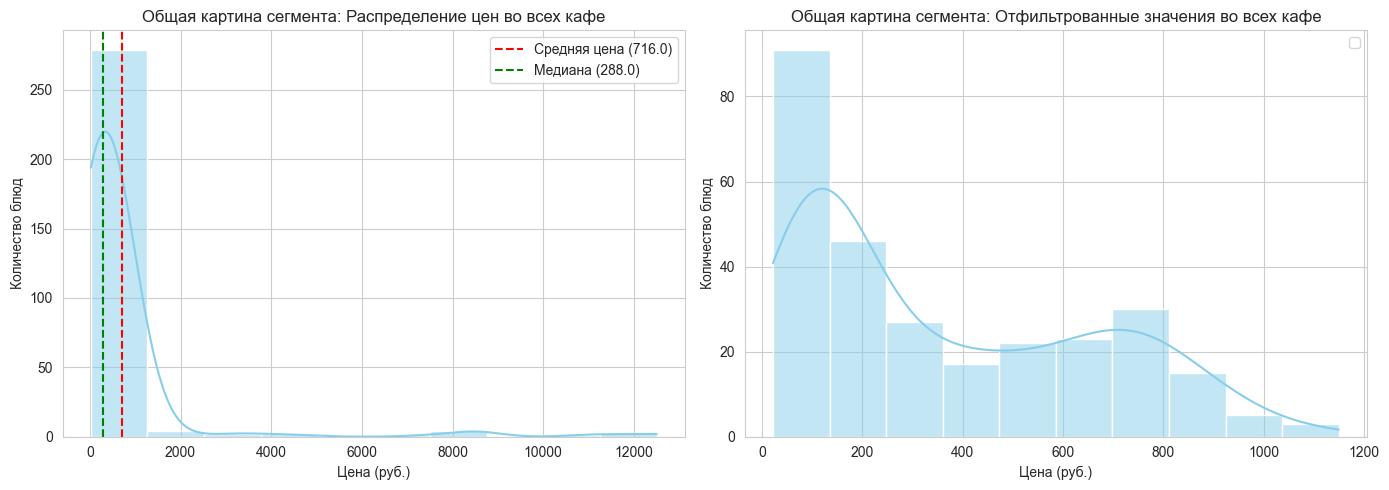

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns


table_all = pd.concat([table_d, table_2, table_3], ignore_index=True)

table_all['Цена']=table_all['Цена'].astype(float)

table_all_filtered = table_all[table_all['Цена'] <= 1250]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=table_all, x='Цена', bins=10, kde=True, color='skyblue', ax=ax1)
ax1.axvline(table_all['Цена'].mean(), color='red', linestyle='--', label=f'Средняя цена ({table_all["Цена"].mean():.1f})')
ax1.axvline(table_all['Цена'].median(), color='green', linestyle='--', label=f'Медиана ({table_all["Цена"].median():.1f})')
ax1.set_title('Общая картина сегмента: Распределение цен во всех кафе')
ax1.set_xlabel('Цена (руб.)')
ax1.set_ylabel('Количество блюд')
ax1.legend()

sns.histplot(data=table_all_filtered, x='Цена', bins=10, kde=True, color='skyblue', ax=ax2)
ax2.set_title('Общая картина сегмента: Отфильтрованные значения во всех кафе')
ax2.set_xlabel('Цена (руб.)')
ax2.set_ylabel('Количество блюд')
ax2.legend()

plt.tight_layout()
plt.show()


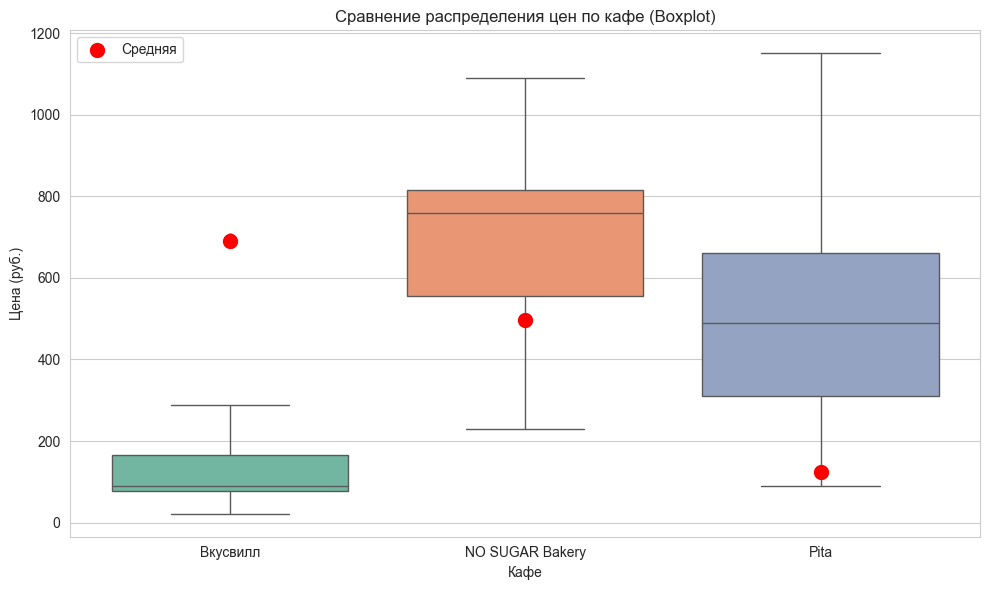

In [29]:
table_all_filtered_2 = pd.concat([
    table_d.assign(Кафе='Вкусвилл'),
    table_2.assign(Кафе='NO SUGAR Bakery'),
    table_3.assign(Кафе='Pita')
], ignore_index=True)

table_all_filtered_2['Цена']=table_all_filtered_2['Цена'].astype(float)

table_all_filtered_2 = table_all_filtered_2[table_all_filtered_2['Цена'] <= 1250]



fig, ax = plt.subplots(1, 1, figsize=(10, 6))

sns.boxplot(data=table_all_filtered_2, x='Кафе', y='Цена', hue='Кафе', palette='Set2', ax=ax)
ax.set_title('Сравнение распределения цен по кафе (Boxplot)')
ax.set_xlabel('Кафе')
ax.set_ylabel('Цена (руб.)')

# Добавим средние значения точками
means = table_all_filtered_2.groupby('Кафе')['Цена'].mean()
for i, cafe in enumerate(means.index):
    ax.scatter(i, means[cafe], color='red', s=100, zorder=5, label='Средняя' if i == 0 else '')
ax.legend()

plt.tight_layout()
plt.show()